# Gaussian Process (GP) Volatility Surface

This notebook fits a Gaussian Process model to the implied volatility surface by modeling **total variance** as a function of log-moneyness and time-to-expiration. Working in total variance is convenient because it puts the maturity dependence into a scale that is smoother across expiries, and implied volatility can then be recovered analytically.

This is an unconstrained GP baseline: it can fit surface structure well, but it does not natively enforce no-arbitrage conditions. Part of the analysis below is therefore to compare predictive accuracy with static arbitrage diagnostics.

Runtime note: GP training scales poorly with sample size, so this notebook uses subsampling by default to keep fitting practical.

## Mathematical Formulation

Let $x = (\ell, \tau) \in \mathbb{R}^2$, where $\ell$ denotes log-moneyness and $\tau$ denotes time-to-expiration. The object modeled in this notebook is the **total variance surface**
$$
f(x) = w(\ell, \tau).
$$
For observed option quotes we therefore write
$$
y_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma_\varepsilon^2),
$$
with $x_i = (\ell_i, \tau_i)$. The implied volatility is then recovered by the deterministic transformation
$$
\sigma_{\mathrm{imp}}(\ell, \tau) = \sqrt{\frac{f(\ell, \tau)}{\tau}}.
$$

A Gaussian Process prior places a probability law on the entire function $f$. Concretely, one assumes
$$
f \sim \mathcal{GP}(m, k),
$$
meaning that for every finite collection $x_1, \dots, x_n$, the random vector
$$
\bigl(f(x_1), \dots, f(x_n)\bigr)^\top
$$
is multivariate normal with mean vector $\bigl(m(x_1), \dots, m(x_n)\bigr)^\top$ and covariance matrix $K$ defined by
$$
K_{ij} = k(x_i, x_j).
$$

Given training inputs $X = (x_1, \dots, x_n)$ and observations $y = (y_1, \dots, y_n)^\top$, the posterior at test inputs $X_*$ is again Gaussian. Writing
$$
K = k(X,X), \qquad K_* = k(X, X_*), \qquad K_{**} = k(X_*, X_*),
$$
the conditional law is
$$
f_* \mid X, y, X_* \sim \mathcal{N}(\mu_*, \Sigma_*),
$$
with posterior mean and covariance
$$
\mu_* = m(X_*) + K_*^\top (K + \sigma_\varepsilon^2 I)^{-1}(y - m(X)),
$$
$$
\Sigma_* = K_{**} - K_*^\top (K + \sigma_\varepsilon^2 I)^{-1} K_*.
$$
Thus the GP supplies both a point prediction and a full posterior covariance structure over the surface values.

In this notebook the kernel has the form
$$
k(x,x') = c\, k_{\mathrm{Matern}}(x,x') + \sigma_n^2 \, \delta_{x,x'},
$$
where $c > 0$ is a scale factor, $k_{\mathrm{Matern}}$ is a Matern covariance kernel, and $\delta_{x,x'}$ denotes the Kronecker delta contribution represented numerically by the white-noise kernel. The Matern component allows a controllable degree of roughness in the fitted surface, while the white-noise term regularizes the fit and absorbs quote-level noise.

The hyperparameters are estimated by maximizing the log marginal likelihood
$$
\log p(y \mid X, \theta)
$$
$$
= -\frac12 (y-m(X))^\top (K_\theta + \sigma_\varepsilon^2 I)^{-1}(y-m(X))
$$
$$
\phantom{=}\; - \frac12 \log \det (K_\theta + \sigma_\varepsilon^2 I) - \frac{n}{2}\log(2\pi),
$$
where $\theta$ collects the kernel parameters. This is the standard Bayesian tradeoff between data fit and complexity: the quadratic term rewards interpolation of the observations, while the log-determinant penalizes overly flexible covariance structures.

Two implementation details are worth noting. First, the inputs and targets are standardized before fitting, which improves numerical conditioning and makes kernel hyperparameter optimization substantially more stable. Second, because GP regression requires linear algebra on the $n \times n$ covariance matrix, naive training cost is typically cubic in the number of training points. That computational scaling is the reason this notebook deliberately subsamples each daily surface before fitting.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, WhiteKernel, Matern
from sklearn.preprocessing import StandardScaler

# Suppress noisy optimizer warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

if "axes3d.mouserotationstyle" in plt.rcParams:
    plt.rcParams["axes3d.mouserotationstyle"] = "azel"

We begin by loading the processed option-surface data and restricting attention to the columns needed for GP fitting and evaluation. The resulting data set contains observations indexed by ticker, quote date, log-moneyness, and time to expiration, together with observed implied volatility and total variance.

In [2]:
DATA_PATH = "../Processed_data/surface_test.parquet"
df = pd.read_parquet(DATA_PATH)
df = df.dropna(subset=["ticker", "quote_date", "log_moneyness", "tau", "total_var", "iv"]).copy()
print(f"Loaded {len(df):,} rows from {DATA_PATH}")
print("Tickers:", sorted(df["ticker"].unique().tolist()))

Loaded 679,076 rows from ../Processed_data/surface_test.parquet
Tickers: ['AAPL', 'NVDA', 'QQQ', 'SLV', 'SPX', 'TSLA']


For a fixed daily surface, we split the observations into a training subset and a holdout subset. This lets us separate interpolation quality from genuine out-of-sample performance, while the cap on training size keeps the GP fit computationally manageable.

In [3]:
def split_train_holdout(frame: pd.DataFrame, train_size: int, seed: int | None = None):
    if len(frame) <= 1:
        raise ValueError("Need at least 2 observations to create train/holdout split.")

    n_train = min(train_size, len(frame) - 1)
    train_df = frame.sample(n=n_train, random_state=seed)
    holdout_df = frame.drop(train_df.index)
    return train_df, holdout_df

In [4]:
TRAIN_SET_SIZE = 1000
RANDOM_STATE = 0

TICKER = "SPX"  # Set to None to sample across all tickers
QUOTE_DATE = None  # Example: "2023-01-30"; if None, sample one date within TICKER

if TICKER is not None:
    ticker_df = df[df["ticker"] == TICKER].copy()
    if ticker_df.empty:
        raise ValueError(f"No rows found for ticker {TICKER}.")

    if QUOTE_DATE is not None:
        surface_all_df = ticker_df[ticker_df["quote_date"].astype(str) == str(QUOTE_DATE)].copy()
        if surface_all_df.empty:
            raise ValueError(f"No rows found for TICKER={TICKER}, QUOTE_DATE={QUOTE_DATE}.")
        ticker = TICKER
        date = str(QUOTE_DATE)
    else:
        available_dates = ticker_df["quote_date"].drop_duplicates().sort_values().to_numpy()
        rng = np.random.default_rng(RANDOM_STATE)
        date = available_dates[rng.integers(len(available_dates))]
        ticker = TICKER
        surface_all_df = ticker_df[ticker_df["quote_date"] == date].copy()
else:
    ticker_date_combos = list(df.groupby(["ticker", "quote_date"]).size().index)
    rng = np.random.default_rng(RANDOM_STATE)
    random_index = rng.integers(len(ticker_date_combos))
    ticker, date = ticker_date_combos[random_index]
    surface_all_df = df[(df["ticker"] == ticker) & (df["quote_date"] == date)].copy()

surface_df, surface_compare_df = split_train_holdout(surface_all_df, TRAIN_SET_SIZE, seed=RANDOM_STATE)

print(f"Selected surface: {ticker} | {date}")
print(f"Total observations: {len(surface_all_df)}")
print(f"Train: {len(surface_df)} | Holdout: {len(surface_compare_df)}")

Selected surface: SPX | 2023-12-15T00:00:00.000000000
Total observations: 6581
Train: 1000 | Holdout: 5581


The GP is trained on total variance rather than implied volatility itself. Once the model produces a prediction for $w(\ell,\tau)$, implied volatility is recovered through

$$\sigma_{\text{imp}} = \sqrt{\frac{w}{\tau}}.$$

The inputs are log-moneyness and $\tau$, so the model is learning a two-dimensional surface rather than a family of independent smile curves.

In [5]:
def fit_gp_surface(train_df: pd.DataFrame, random_state: int = 0):
    X = np.column_stack([
        train_df["log_moneyness"].to_numpy(),
        train_df["tau"].to_numpy(),
    ])
    y = train_df["total_var"].to_numpy()

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    Xs = x_scaler.fit_transform(X)
    ys = y_scaler.fit_transform(y.reshape(-1, 1)).ravel()

    kernel = (
        ConstantKernel(1.0, (1e-3, 1e3))
        * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3))
        + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        random_state=random_state,
    )
    gp.fit(Xs, ys)

    return gp, x_scaler, y_scaler


def predict_total_var(gp, x_scaler, y_scaler, X_raw: np.ndarray):
    Xs = x_scaler.transform(X_raw)
    mu_s, sigma_s = gp.predict(Xs, return_std=True)

    mu = y_scaler.inverse_transform(mu_s.reshape(-1, 1)).ravel()
    sigma = sigma_s * y_scaler.scale_[0]

    return mu, sigma


gp, x_scaler, y_scaler = fit_gp_surface(surface_df, random_state=RANDOM_STATE)
print("Fitted kernel:", gp.kernel_)

Fitted kernel: 23.3**2 * Matern(length_scale=[39.4, 46.6], nu=1.5) + WhiteKernel(noise_level=2.76e-05)


We first examine one-dimensional smile slices by fixing maturity and varying log-moneyness. These plots show how the fitted GP interpolates the surface locally and how its predictions compare with holdout points near the same maturity.

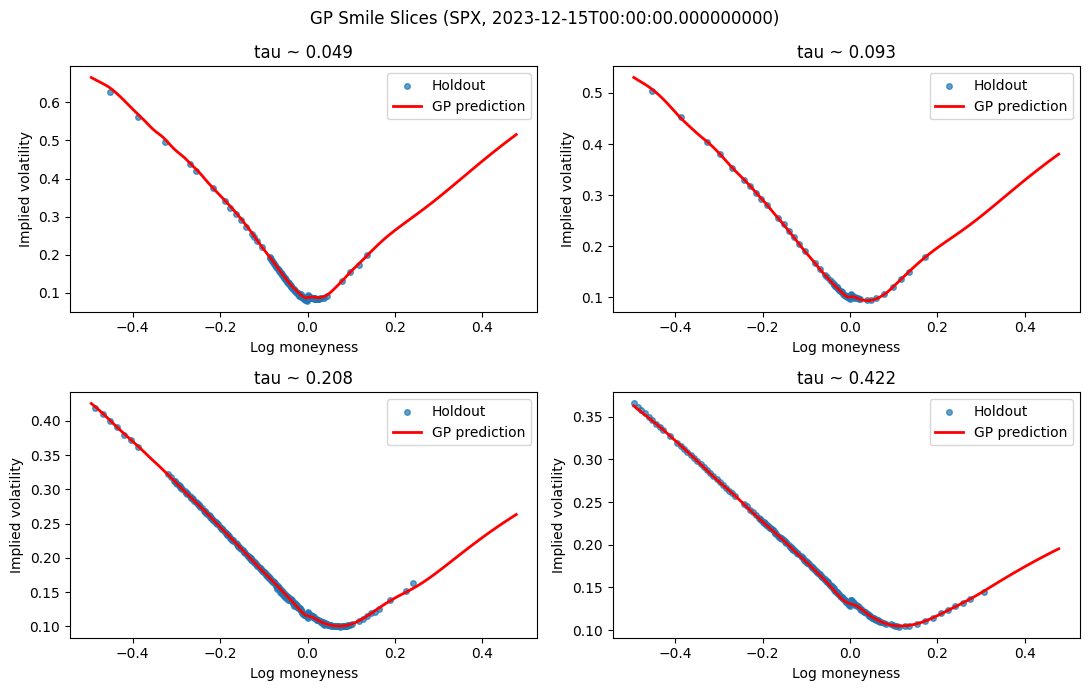

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

tau_values = np.quantile(surface_all_df["tau"], [0.15, 0.35, 0.65, 0.85])
lm_min = surface_all_df["log_moneyness"].min()
lm_max = surface_all_df["log_moneyness"].max()
lm_line = np.linspace(lm_min, lm_max, 120)

for ax, tau0 in zip(axes, tau_values):
    X_line = np.column_stack([lm_line, np.full_like(lm_line, tau0)])
    mu_tv, _ = predict_total_var(gp, x_scaler, y_scaler, X_line)
    mu_tv = np.clip(mu_tv, 1e-12, None)
    iv_line = np.sqrt(mu_tv / np.maximum(tau0, 1e-12))

    band = 0.02 * max(float(tau0), 1e-6)
    hold_slice = surface_compare_df[np.abs(surface_compare_df["tau"] - tau0) <= band]

    if len(hold_slice) > 0:
        ax.scatter(hold_slice["log_moneyness"], hold_slice["iv"], s=16, alpha=0.7, label="Holdout")

    ax.plot(lm_line, iv_line, color="red", linewidth=2, label="GP prediction")
    ax.set_title(f"tau ~ {tau0:.3f}")
    ax.set_xlabel("Log moneyness")
    ax.set_ylabel("Implied volatility")
    ax.legend()

plt.suptitle(f"GP Smile Slices ({ticker}, {date})")
plt.tight_layout()

To see how the fit behaves across the year for a single ticker, we also plot smile curves on several quote dates. This gives a qualitative sense of how stable the GP is across changing market regimes rather than just across maturities on one day.

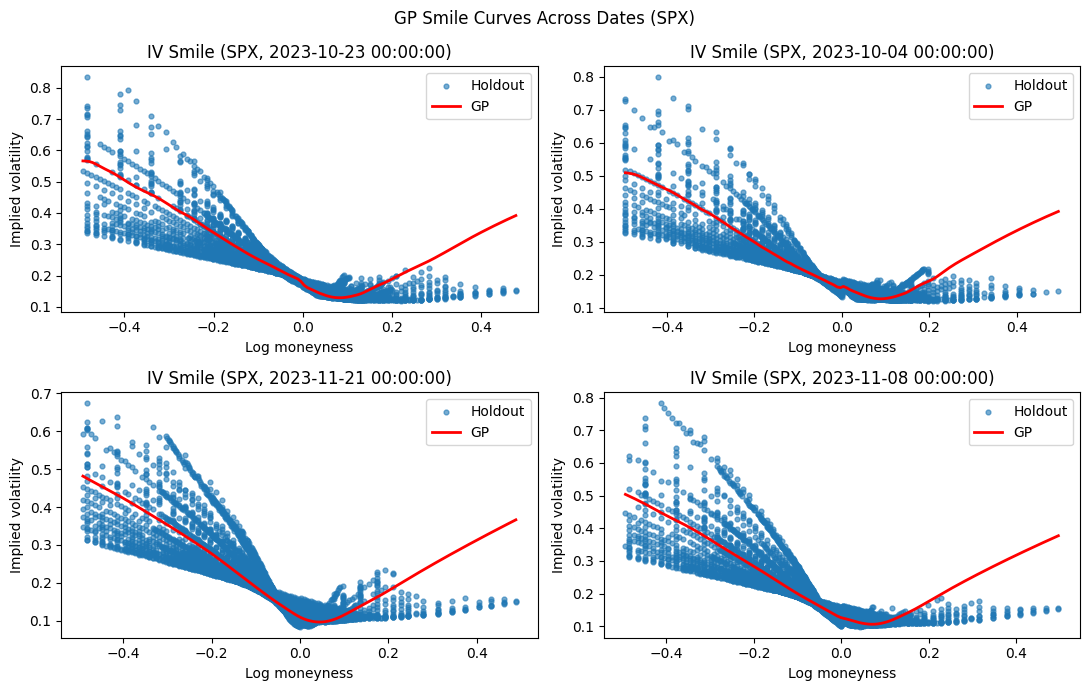

In [7]:
SMILE_TICKER = TICKER if TICKER is not None else ticker
SMILE_DAYS = 4
SMILE_RANDOM_STATE = 7

smile_df = df[df["ticker"] == SMILE_TICKER].copy()
if smile_df.empty:
    raise ValueError(f"No rows found for SMILE_TICKER={SMILE_TICKER}.")

sampled_dates = smile_df["quote_date"].drop_duplicates().sample(
    n=min(SMILE_DAYS, smile_df["quote_date"].nunique()),
    random_state=SMILE_RANDOM_STATE,
).tolist()

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()

for ax, qd in zip(axes, sampled_dates):
    day_frame = smile_df[smile_df["quote_date"] == qd].copy()
    if len(day_frame) < 20:
        ax.set_title(f"{qd}: not enough points")
        ax.axis("off")
        continue

    train_day, hold_day = split_train_holdout(day_frame, TRAIN_SET_SIZE, seed=SMILE_RANDOM_STATE)
    gp_day, xs_day, ys_day = fit_gp_surface(train_day, random_state=SMILE_RANDOM_STATE)

    lm_day = np.linspace(day_frame["log_moneyness"].min(), day_frame["log_moneyness"].max(), 140)
    tau0 = float(day_frame["tau"].median())
    X_line = np.column_stack([lm_day, np.full_like(lm_day, tau0)])
    mu_tv_day, _ = predict_total_var(gp_day, xs_day, ys_day, X_line)
    mu_tv_day = np.clip(mu_tv_day, 1e-12, None)
    iv_line = np.sqrt(mu_tv_day / max(tau0, 1e-12))

    ax.scatter(hold_day["log_moneyness"], hold_day["iv"], s=12, alpha=0.6, label="Holdout")
    ax.plot(lm_day, iv_line, color="red", linewidth=2, label="GP")
    ax.set_title(f"IV Smile ({SMILE_TICKER}, {qd})")
    ax.set_xlabel("Log moneyness")
    ax.set_ylabel("Implied volatility")
    ax.legend()

for j in range(len(sampled_dates), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"GP Smile Curves Across Dates ({SMILE_TICKER})")
plt.tight_layout()
plt.show()

We next visualize the fitted surface directly in two ways: as total variance and as implied volatility. The first is the object learned by the GP, while the second is the quantity that is easier to compare with market convention and with other smile models.

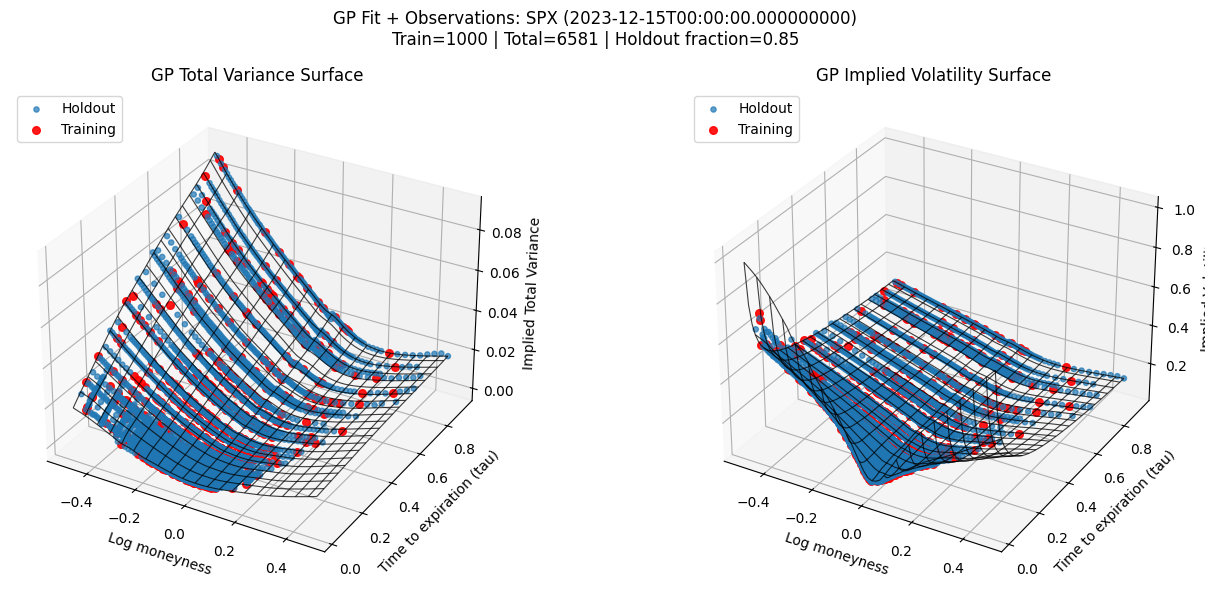

In [8]:
GRID_SIZE = 60
lm = np.linspace(surface_all_df["log_moneyness"].min(), surface_all_df["log_moneyness"].max(), GRID_SIZE)
tt = np.linspace(surface_all_df["tau"].min(), surface_all_df["tau"].max(), GRID_SIZE)
LM, TT = np.meshgrid(lm, tt)
Xg = np.column_stack([LM.ravel(), TT.ravel()])

mu_tv, sigma_tv = predict_total_var(gp, x_scaler, y_scaler, Xg)
mu_tv = np.clip(mu_tv, 1e-12, None)
MU = mu_tv.reshape(LM.shape)
SIGMA = sigma_tv.reshape(LM.shape)
IV = np.sqrt(MU / np.maximum(TT, 1e-12))

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

for ax, z_pred, z_col, z_label, title in [
    (ax1, MU, "total_var", "Implied Total Variance", "GP Total Variance Surface"),
    (ax2, IV, "iv", "Implied Volatility", "GP Implied Volatility Surface"),
]:
    ax.plot_wireframe(
        LM, TT, z_pred,
        rstride=3, cstride=3,
        color="black", linewidth=0.8, alpha=0.75,
    )

    ax.scatter(
        surface_compare_df["log_moneyness"],
        surface_compare_df["tau"],
        surface_compare_df[z_col],
        color="tab:blue", s=14, alpha=0.7, depthshade=True, label="Holdout",
    )

    ax.scatter(
        surface_df["log_moneyness"],
        surface_df["tau"],
        surface_df[z_col],
        color="red", s=30, alpha=0.9, depthshade=False, label="Training",
    )

    ax.set_xlabel("Log moneyness")
    ax.set_ylabel("Time to expiration (tau)")
    ax.set_zlabel(z_label)
    ax.set_title(title)
    ax.legend(loc="upper left")

holdout_frac = 1 - len(surface_df) / len(surface_all_df)
plt.suptitle(
    f"GP Fit + Observations: {ticker} ({date})\n"
    f"Train={len(surface_df)} | Total={len(surface_all_df)} | Holdout fraction={holdout_frac:.2f}"
)
plt.tight_layout()
plt.show()

Predictive fit alone is not enough for an option surface model; the surface should also satisfy static no-arbitrage conditions. We therefore check two diagnostics: a butterfly condition based on the smile-space quantity $g(k)$, and a calendar condition requiring $w(k,\tau)$ to be non-decreasing in maturity at fixed $k$.

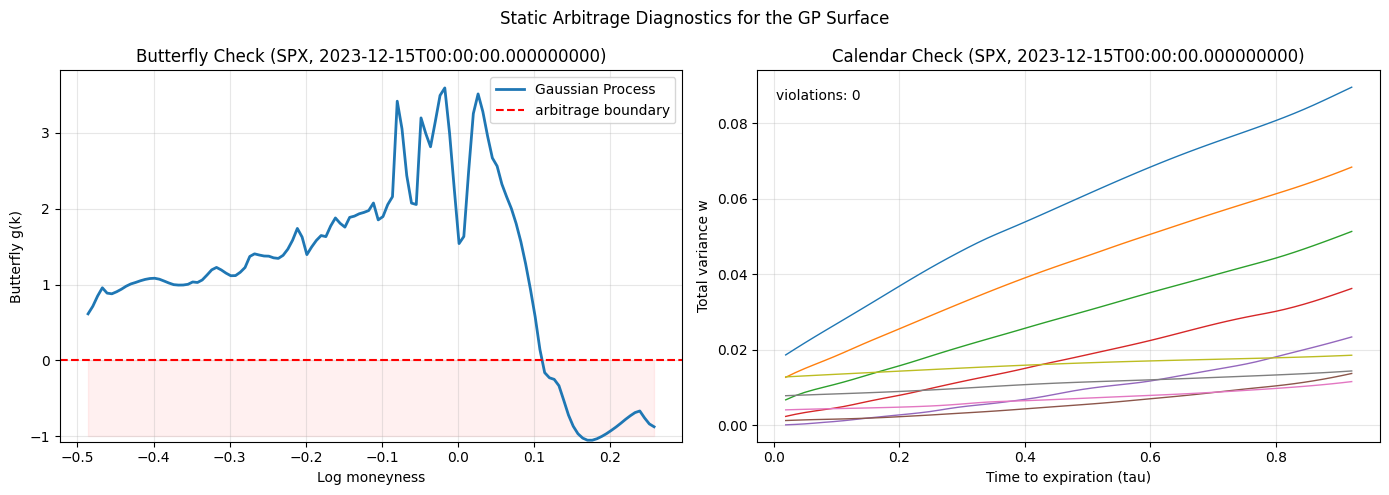

Butterfly check: min g(k) = -1.0510e+00; negative grid points = 24
Calendar check: 0 decreases of w in tau across 9 fixed-k lines


In [9]:
def gp_surface_w(k_vals, tau_vals):
    k_arr, tau_arr = np.broadcast_arrays(
        np.asarray(k_vals, dtype=float),
        np.asarray(tau_vals, dtype=float),
    )
    X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
    mu_tv, _ = predict_total_var(gp, x_scaler, y_scaler, X_raw)
    return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)


if "expire_date" in surface_all_df.columns:
    rep_expiry = surface_all_df["expire_date"].value_counts().idxmax()
    rep_slice = surface_all_df[surface_all_df["expire_date"] == rep_expiry].copy()
else:
    rep_slice = surface_all_df.copy()

tau_g = float(rep_slice["tau"].median())
kline = np.linspace(rep_slice["log_moneyness"].min(), rep_slice["log_moneyness"].max(), 120)
eps_k = max(1e-5, 1e-4 * (kline.max() - kline.min()))


def butterfly_g(w_fn, k, tau, eps=eps_k):
    tau_vec = np.full_like(k, tau, dtype=float)
    w = np.asarray(w_fn(k, tau_vec), dtype=float)
    wk = (np.asarray(w_fn(k + eps, tau_vec), dtype=float) - np.asarray(w_fn(k - eps, tau_vec), dtype=float)) / (2 * eps)
    wkk = (np.asarray(w_fn(k + eps, tau_vec), dtype=float) - 2 * w + np.asarray(w_fn(k - eps, tau_vec), dtype=float)) / (eps ** 2)

    g = np.full_like(w, np.nan, dtype=float)
    mask = w > 1e-8
    g[mask] = (1 - k[mask] * wk[mask] / (2 * w[mask])) ** 2 - (wk[mask] / 4) * (1 / w[mask] + 0.25) + wkk[mask] / 2
    return g


g_curve = butterfly_g(gp_surface_w, kline, tau_g)
negative_g = int(np.sum(g_curve < -1e-8))
worst_g = float(np.nanmin(g_curve))

tau_fine = np.linspace(surface_all_df["tau"].min(), surface_all_df["tau"].max(), 60)
k_fixed = np.linspace(surface_all_df["log_moneyness"].min(), surface_all_df["log_moneyness"].max(), 9)
cal_lines = np.array([gp_surface_w(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
calendar_violations = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(kline, g_curve, color="tab:blue", linewidth=2, label="Gaussian Process")
ax1.axhline(0.0, color="red", linestyle="--", linewidth=1.5, label="arbitrage boundary")
ax1.fill_between(kline, -1, 0, color="red", alpha=0.06)
ax1.set_ylim(bottom=min(-0.2, np.nanmin(g_curve) - 0.02))
ax1.set_xlabel("Log moneyness")
ax1.set_ylabel("Butterfly g(k)")
ax1.set_title(f"Butterfly Check ({ticker}, {date})")
ax1.legend()
ax1.grid(alpha=0.3)

for line, k0 in zip(cal_lines, k_fixed):
    ax2.plot(tau_fine, line, linewidth=1, label=f"k={k0:.2f}")
ax2.set_xlabel("Time to expiration (tau)")
ax2.set_ylabel("Total variance w")
ax2.set_title(f"Calendar Check ({ticker}, {date})")
ax2.text(0.03, 0.95, f"violations: {calendar_violations}", transform=ax2.transAxes, va="top")
ax2.grid(alpha=0.3)

plt.suptitle("Static Arbitrage Diagnostics for the GP Surface")
plt.tight_layout()
plt.show()

arb_curves = {
    "kline": kline,
    "tau_g": tau_g,
    "day": str(date),
    "tau_fine": tau_fine,
    "k_fixed": k_fixed,
    "g": {"Gaussian Process": g_curve},
    "cal": {"Gaussian Process": cal_lines},
}

print(f"Butterfly check: min g(k) = {worst_g:+.4e}; negative grid points = {negative_g}")
print(f"Calendar check: {calendar_violations} decreases of w in tau across {len(k_fixed)} fixed-k lines")

After examining the geometry of the fitted surface, we evaluate out-of-sample prediction quality on the holdout set. These summary metrics quantify how well the GP generalizes beyond the points used during fitting.

In [10]:
X_hold = np.column_stack([
    surface_compare_df["log_moneyness"].to_numpy(),
    surface_compare_df["tau"].to_numpy(),
])

mu_tv_hold, _ = predict_total_var(gp, x_scaler, y_scaler, X_hold)
mu_tv_hold = np.clip(mu_tv_hold, 1e-12, None)
pred_iv_hold = np.sqrt(mu_tv_hold / np.maximum(surface_compare_df["tau"].to_numpy(), 1e-12))

obs_tv_hold = surface_compare_df["total_var"].to_numpy()
obs_iv_hold = surface_compare_df["iv"].to_numpy()

rmse_tv = np.sqrt(np.mean((mu_tv_hold - obs_tv_hold) ** 2))
rmse_iv = np.sqrt(np.mean((pred_iv_hold - obs_iv_hold) ** 2))
mae_tv = np.mean(np.abs(mu_tv_hold - obs_tv_hold))
mae_iv = np.mean(np.abs(pred_iv_hold - obs_iv_hold))

mse_iv = np.mean((pred_iv_hold - obs_iv_hold) ** 2)

print(f"Holdout RMSE (total variance): {rmse_tv:.6f}")
print(f"Holdout MAE  (total variance): {mae_tv:.6f}")
print(f"Holdout RMSE (implied vol):    {rmse_iv:.6f}")
print(f"Holdout MAE  (implied vol):    {mae_iv:.6f}")
print(f"Holdout MSE  (implied vol):    {mse_iv:.6f}")

Holdout RMSE (total variance): 0.000153
Holdout MAE  (total variance): 0.000076
Holdout RMSE (implied vol):    0.002708
Holdout MAE  (implied vol):    0.001599
Holdout MSE  (implied vol):    0.000007


It is also useful to inspect the residuals directly. A prediction model can have an acceptable aggregate error while still showing systematic bias, heavy tails, or maturity-dependent heteroskedasticity, and these plots help reveal such patterns.

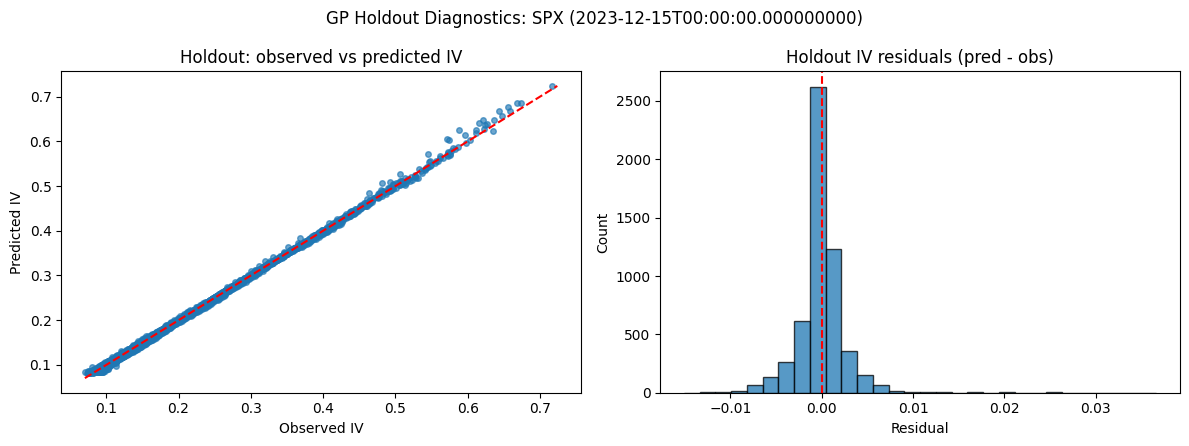

IV residual mean: -0.000033
IV residual std:  0.002708
TV residual mean: 0.000001
TV residual std:  0.000153


In [11]:
resid_iv = pred_iv_hold - obs_iv_hold
resid_tv = mu_tv_hold - obs_tv_hold

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(obs_iv_hold, pred_iv_hold, s=16, alpha=0.65)
lim_min = min(obs_iv_hold.min(), pred_iv_hold.min())
lim_max = max(obs_iv_hold.max(), pred_iv_hold.max())
axes[0].plot([lim_min, lim_max], [lim_min, lim_max], color="red", linewidth=1.5, linestyle="--")
axes[0].set_title("Holdout: observed vs predicted IV")
axes[0].set_xlabel("Observed IV")
axes[0].set_ylabel("Predicted IV")

axes[1].hist(resid_iv, bins=30, alpha=0.75, color="tab:blue", edgecolor="black")
axes[1].axvline(0.0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Holdout IV residuals (pred - obs)")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

plt.suptitle(f"GP Holdout Diagnostics: {ticker} ({date})")
plt.tight_layout()
plt.show()

print(f"IV residual mean: {np.mean(resid_iv):.6f}")
print(f"IV residual std:  {np.std(resid_iv):.6f}")
print(f"TV residual mean: {np.mean(resid_tv):.6f}")
print(f"TV residual std:  {np.std(resid_tv):.6f}")

Finally, we repeat the holdout evaluation across several quote dates for a fixed ticker. This gives a broader view of day-to-day robustness.

In [12]:
def evaluate_day_gp(frame: pd.DataFrame, train_size: int, seed: int = 0):
    train_df, holdout_df = split_train_holdout(frame, train_size, seed=seed)
    gp_local, x_scaler_local, y_scaler_local = fit_gp_surface(train_df, random_state=seed)

    X_hold_local = np.column_stack([
        holdout_df["log_moneyness"].to_numpy(),
        holdout_df["tau"].to_numpy(),
    ])
    mu_tv_hold_local, _ = predict_total_var(gp_local, x_scaler_local, y_scaler_local, X_hold_local)
    mu_tv_hold_local = np.clip(mu_tv_hold_local, 1e-12, None)
    pred_iv_hold_local = np.sqrt(mu_tv_hold_local / np.maximum(holdout_df["tau"].to_numpy(), 1e-12))

    obs_tv_hold_local = holdout_df["total_var"].to_numpy()
    obs_iv_hold_local = holdout_df["iv"].to_numpy()

    rmse_tv_local = np.sqrt(np.mean((mu_tv_hold_local - obs_tv_hold_local) ** 2))
    rmse_iv_local = np.sqrt(np.mean((pred_iv_hold_local - obs_iv_hold_local) ** 2))
    mae_tv_local = np.mean(np.abs(mu_tv_hold_local - obs_tv_hold_local))
    mae_iv_local = np.mean(np.abs(pred_iv_hold_local - obs_iv_hold_local))

    mse_iv_local = np.mean((pred_iv_hold_local - obs_iv_hold_local) ** 2)

    return {
        "n_total": len(frame),
        "n_train": len(train_df),
        "n_holdout": len(holdout_df),
        "rmse_tv": rmse_tv_local,
        "mae_tv": mae_tv_local,
        "rmse_iv": rmse_iv_local,
        "mae_iv": mae_iv_local,
        "mse_iv": mse_iv_local,
    }


EVAL_TICKER = "SPX"  # Set evaluation ticker explicitly
EVAL_DAYS = 7
EVAL_RANDOM_STATE = 1

ticker_df = df[df["ticker"] == EVAL_TICKER].copy()
if ticker_df.empty:
    raise ValueError(f"No rows found for EVAL_TICKER={EVAL_TICKER}.")

candidate_dates = ticker_df["quote_date"].drop_duplicates().sample(
    n=min(EVAL_DAYS, ticker_df["quote_date"].nunique()),
    random_state=EVAL_RANDOM_STATE,
).tolist()

rows = []
for i, qd in enumerate(candidate_dates):
    day_frame = ticker_df[ticker_df["quote_date"] == qd].copy()
    if len(day_frame) < 15:
        continue
    metrics = evaluate_day_gp(day_frame, train_size=TRAIN_SET_SIZE, seed=EVAL_RANDOM_STATE + i)
    metrics["quote_date"] = str(qd)
    rows.append(metrics)

summary_df = pd.DataFrame(rows).sort_values("quote_date").reset_index(drop=True)
summary_df = summary_df[[
    "quote_date", "n_total", "n_train", "n_holdout",
    "rmse_tv", "mae_tv", "rmse_iv", "mae_iv", "mse_iv"
]]

print(f"Per-day GP holdout metrics for ticker={EVAL_TICKER}")
display(summary_df)

if len(summary_df) > 0:
    print("\nAverage metrics across sampled days:")
    display(summary_df[["rmse_tv", "mae_tv", "rmse_iv", "mae_iv", "mse_iv"]].mean().to_frame("mean").T)

Per-day GP holdout metrics for ticker=SPX


,quote_date,n_total,n_train,n_holdout,rmse_tv,mae_tv,rmse_iv,mae_iv,mse_iv
0,2023-10-04 00:00:00,6287,1000,5287,0.000136,0.000075,0.002609,0.001541,0.000007
1,2023-10-31 00:00:00,6185,1000,5185,0.000163,0.000077,0.002539,0.001452,0.000006
2,2023-11-03 00:00:00,6355,1000,5355,0.000155,0.000062,0.001963,0.000919,0.000004
3,2023-11-08 00:00:00,6266,1000,5266,0.000123,0.000060,0.001971,0.001147,0.000004
4,2023-11-27 00:00:00,6164,1000,5164,0.000106,0.000052,0.001458,0.000849,0.000002
5,2023-12-13 00:00:00,6068,1000,5068,0.000150,0.000067,0.002306,0.001262,0.000005
6,2023-12-28 00:00:00,6681,1000,5681,0.000126,0.000059,0.001967,0.001167,0.000004



Average metrics across sampled days:


,rmse_tv,mae_tv,rmse_iv,mae_iv,mse_iv
mean,0.000137,0.000065,0.002116,0.001191,0.000005


## Discussion: Hyperparameter Tuning and Arbitrage Reduction

The arbitrage diagnostics suggest that the current GP can fit the surface reasonably well while still violating butterfly constraints. Since the kernel controls local curvature in $w(k,\tau)$, arbitrage reduction is largely a problem of regularization and prior design.

With a Matern kernel, very short length scales and a small noise term can make the posterior mean track local quote noise too closely, producing oscillatory curvature and negative values of $g(k)$. Raising the lower bounds on the length scales, shrinking the signal variance, or allowing a larger noise floor may therefore reduce butterfly violations, even if convexity is not enforced exactly.

Kernel choice also matters. A single stationary kernel over $(k,\tau)$ may be too rigid in some regions and too flexible in others, so product, additive, or anisotropic kernels may better reflect the different geometry of strike and maturity. Smoother kernels such as the squared-exponential are also natural candidates if the main issue is excessive local roughness.

A more structural idea is to build the arbitrage conditions into the posterior itself. Because derivatives of a Gaussian Process are again jointly Gaussian, quantities involving $f$, $\partial_k f$, $\partial_{kk} f$, and $\partial_\tau f$ are analytically tractable under the prior and posterior. This makes it plausible to impose derivative-based monotonicity or convexity conditions on a grid through conditioning, virtual observations, or truncated Gaussian constructions.

The main complication is that butterfly no-arbitrage is expressed through the nonlinear quantity $g(k)$, not just a single derivative sign condition. Even so, a constrained posterior or a penalized objective based on $g(k)$ and calendar violations would be more principled than tuning only for predictive fit. The most practical next step is a joint sweep over kernel families and hyperparameters, evaluated simultaneously on holdout error and arbitrage diagnostics.

## Analysis: 2023-12-29 Train/Holdout RMSE and Arbitrage

=== Analysis for SPX on 2023-12-29 ===

Training set (500 samples):
  IV RMSE:  0.001319
  IV MAE:   0.000727

Holdout set (6080 samples):
  IV RMSE:  0.002443
  IV MAE:   0.001450

=== Arbitrage Analysis ===

Butterfly check: min g(k) = -1.4706e+00; negative grid points = 25
Calendar check: 0 decreases of w in tau across 9 fixed-k lines


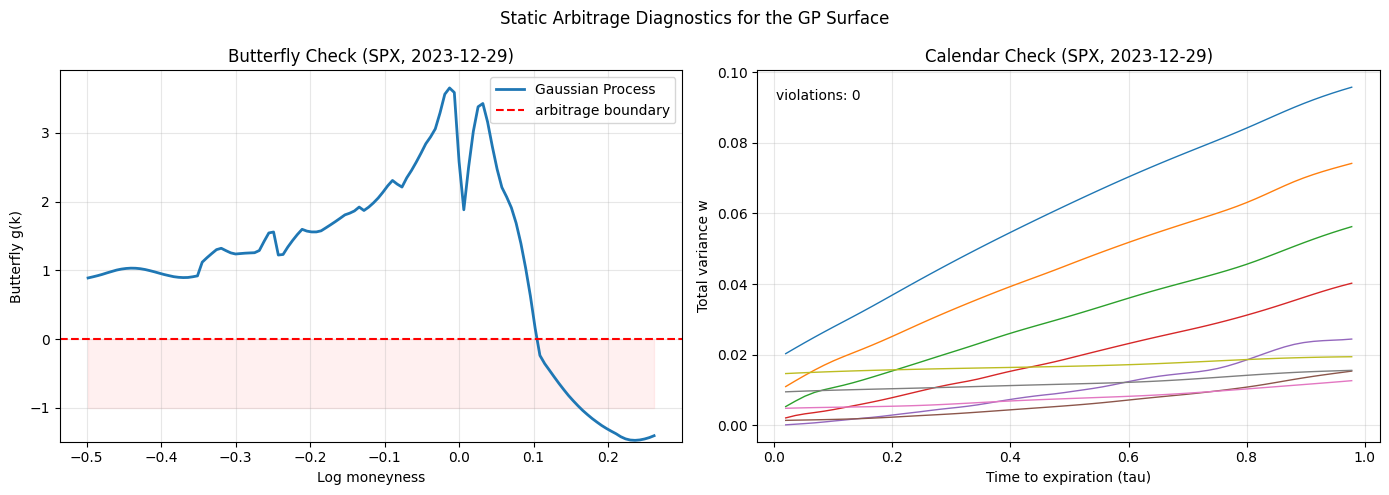

In [13]:
TARGET_DATE = "2023-12-29"
TARGET_TICKER = "SPX"

# Filter data for the target date
target_df = df[(df["quote_date"] == TARGET_DATE) & (df["ticker"] == TARGET_TICKER)].copy()

if target_df.empty:
    print(f"No data found for {TARGET_TICKER} on {TARGET_DATE}")
else:
    # Split into train/holdout
    train_target, holdout_target = split_train_holdout(target_df, train_size=500, seed=0)
    
    # Fit GP on training set
    gp_target, x_scaler_target, y_scaler_target = fit_gp_surface(train_target, random_state=0)
    
    # Predictions on training set
    X_train = np.column_stack([
        train_target["log_moneyness"].to_numpy(),
        train_target["tau"].to_numpy(),
    ])
    mu_tv_train, _ = predict_total_var(gp_target, x_scaler_target, y_scaler_target, X_train)
    mu_tv_train = np.clip(mu_tv_train, 1e-12, None)
    pred_iv_train = np.sqrt(mu_tv_train / np.maximum(train_target["tau"].to_numpy(), 1e-12))
    obs_iv_train = train_target["iv"].to_numpy()
    
    # Predictions on holdout set
    X_holdout = np.column_stack([
        holdout_target["log_moneyness"].to_numpy(),
        holdout_target["tau"].to_numpy(),
    ])
    mu_tv_holdout, _ = predict_total_var(gp_target, x_scaler_target, y_scaler_target, X_holdout)
    mu_tv_holdout = np.clip(mu_tv_holdout, 1e-12, None)
    pred_iv_holdout = np.sqrt(mu_tv_holdout / np.maximum(holdout_target["tau"].to_numpy(), 1e-12))
    obs_iv_holdout = holdout_target["iv"].to_numpy()
    
    # Compute RMSE for both sets
    rmse_iv_train = np.sqrt(np.mean((pred_iv_train - obs_iv_train) ** 2))
    rmse_iv_holdout = np.sqrt(np.mean((pred_iv_holdout - obs_iv_holdout) ** 2))
    mae_iv_train = np.mean(np.abs(pred_iv_train - obs_iv_train))
    mae_iv_holdout = np.mean(np.abs(pred_iv_holdout - obs_iv_holdout))
    
    print(f"=== Analysis for {TARGET_TICKER} on {TARGET_DATE} ===\n")
    print(f"Training set ({len(train_target)} samples):")
    print(f"  IV RMSE:  {rmse_iv_train:.6f}")
    print(f"  IV MAE:   {mae_iv_train:.6f}")
    print(f"\nHoldout set ({len(holdout_target)} samples):")
    print(f"  IV RMSE:  {rmse_iv_holdout:.6f}")
    print(f"  IV MAE:   {mae_iv_holdout:.6f}")
    
    # Arbitrage diagnostics
    def gp_surface_w_target(k_vals, tau_vals):
        k_arr, tau_arr = np.broadcast_arrays(
            np.asarray(k_vals, dtype=float),
            np.asarray(tau_vals, dtype=float),
        )
        X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
        mu_tv, _ = predict_total_var(gp_target, x_scaler_target, y_scaler_target, X_raw)
        return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)
    
    # Get representative slice
    if "expire_date" in target_df.columns:
        rep_expiry = target_df["expire_date"].value_counts().idxmax()
        rep_slice = target_df[target_df["expire_date"] == rep_expiry].copy()
    else:
        rep_slice = target_df.copy()
    
    tau_g = float(rep_slice["tau"].median())
    kline = np.linspace(rep_slice["log_moneyness"].min(), rep_slice["log_moneyness"].max(), 120)
    eps_k = max(1e-5, 1e-4 * (kline.max() - kline.min()))
    
    # Butterfly check
    g_curve = butterfly_g(gp_surface_w_target, kline, tau_g, eps=eps_k)
    negative_g = int(np.sum(g_curve < -1e-8))
    worst_g = float(np.nanmin(g_curve))
    
    # Calendar check
    tau_fine = np.linspace(target_df["tau"].min(), target_df["tau"].max(), 60)
    k_fixed = np.linspace(target_df["log_moneyness"].min(), target_df["log_moneyness"].max(), 9)
    cal_lines = np.array([gp_surface_w_target(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
    calendar_violations = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines))
    
    print(f"\n=== Arbitrage Analysis ===\n")
    print(f"Butterfly check: min g(k) = {worst_g:+.4e}; negative grid points = {negative_g}")
    print(f"Calendar check: {calendar_violations} decreases of w in tau across {len(k_fixed)} fixed-k lines")
    
    # Create arbitrage diagnostic plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(kline, g_curve, color="tab:blue", linewidth=2, label="Gaussian Process")
    ax1.axhline(0.0, color="red", linestyle="--", linewidth=1.5, label="arbitrage boundary")
    ax1.fill_between(kline, -1, 0, color="red", alpha=0.06)
    ax1.set_ylim(bottom=min(-0.2, np.nanmin(g_curve) - 0.02))
    ax1.set_xlabel("Log moneyness")
    ax1.set_ylabel("Butterfly g(k)")
    ax1.set_title(f"Butterfly Check ({TARGET_TICKER}, {TARGET_DATE})")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    for line, k0 in zip(cal_lines, k_fixed):
        ax2.plot(tau_fine, line, linewidth=1, label=f"k={k0:.2f}")
    ax2.set_xlabel("Time to expiration (tau)")
    ax2.set_ylabel("Total variance w")
    ax2.set_title(f"Calendar Check ({TARGET_TICKER}, {TARGET_DATE})")
    ax2.text(0.03, 0.95, f"violations: {calendar_violations}", transform=ax2.transAxes, va="top")
    ax2.grid(alpha=0.3)
    
    plt.suptitle("Static Arbitrage Diagnostics for the GP Surface")
    plt.tight_layout()
    plt.show()

## Hyperparameter Tuning: Reducing Arbitrage Violations (2023-12-29)

In [14]:
from sklearn.gaussian_process.kernels import RBF
import time

kernel_configs = [
    ("Matern(1.5) base", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("Matern(2.5) smoother", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("Matern(2.5) + med noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=5e-4, noise_level_bounds=(1e-4, 1e-1))),
    ("Matern(2.5) + high noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("Matern(2.5) reg'd length", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(5e-2, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("RBF (smooth)", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("RBF + med noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=5e-4, noise_level_bounds=(1e-4, 1e-1))),
    ("RBF + high noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("RBF + reg'd length", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(5e-2, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("Matern(1.5) + high noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("Matern(1.5) reg'd length", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-1, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("Matern(2.5) agg reg", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-1, 1e3)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("RBF + very high noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=2e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("Matern(2.5) reg + high noise", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(5e-2, 1e3)) + WhiteKernel(noise_level=1.5e-3, noise_level_bounds=(1e-4, 1e-1))),
    ("Matern(0.5) rough", 
     lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=0.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
    ("Matern(1.5) low signal", 
     lambda: ConstantKernel(1.0, (1e-3, 1e2)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
]

results = []

print(f"Tuning {len(kernel_configs)} kernel configurations on {TARGET_TICKER} ({TARGET_DATE})")
print("=" * 100)

for config_name, kernel_fn in kernel_configs:
    try:
        start_time = time.time()

        kernel = kernel_fn()
        gp_tune = GaussianProcessRegressor(kernel=kernel, normalize_y=False, random_state=0)
        
        X_train_tune = np.column_stack([
            train_target["log_moneyness"].to_numpy(),
            train_target["tau"].to_numpy(),
        ])
        y_train_tune = train_target["total_var"].to_numpy()
        
        x_scaler_tune = StandardScaler()
        y_scaler_tune = StandardScaler()
        X_train_scaled = x_scaler_tune.fit_transform(X_train_tune)
        y_train_scaled = y_scaler_tune.fit_transform(y_train_tune.reshape(-1, 1)).ravel()
        
        gp_tune.fit(X_train_scaled, y_train_scaled)
        fit_time = time.time() - start_time
        
        # Train RMSE
        mu_tv_train_tune, _ = predict_total_var(gp_tune, x_scaler_tune, y_scaler_tune, X_train_tune)
        mu_tv_train_tune = np.clip(mu_tv_train_tune, 1e-12, None)
        pred_iv_train_tune = np.sqrt(mu_tv_train_tune / np.maximum(train_target["tau"].to_numpy(), 1e-12))
        obs_iv_train_tune = train_target["iv"].to_numpy()
        rmse_iv_train = np.sqrt(np.mean((pred_iv_train_tune - obs_iv_train_tune) ** 2))
        
        X_hold_tune = np.column_stack([
            holdout_target["log_moneyness"].to_numpy(),
            holdout_target["tau"].to_numpy(),
        ])
        mu_tv_hold_tune, _ = predict_total_var(gp_tune, x_scaler_tune, y_scaler_tune, X_hold_tune)
        mu_tv_hold_tune = np.clip(mu_tv_hold_tune, 1e-12, None)
        pred_iv_hold_tune = np.sqrt(mu_tv_hold_tune / np.maximum(holdout_target["tau"].to_numpy(), 1e-12))
        obs_iv_hold_tune = holdout_target["iv"].to_numpy()
        
        rmse_iv_hold = np.sqrt(np.mean((pred_iv_hold_tune - obs_iv_hold_tune) ** 2))
        
        def gp_surface_w_tune(k_vals, tau_vals):
            k_arr, tau_arr = np.broadcast_arrays(
                np.asarray(k_vals, dtype=float),
                np.asarray(tau_vals, dtype=float),
            )
            X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
            mu_tv, _ = predict_total_var(gp_tune, x_scaler_tune, y_scaler_tune, X_raw)
            return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)
        
        # Butterfly check
        g_curve_tune = butterfly_g(gp_surface_w_tune, kline, tau_g, eps=eps_k)
        neg_g_tune = int(np.sum(g_curve_tune < -1e-8))
        worst_g_tune = float(np.nanmin(g_curve_tune))
        
        # Calendar check
        cal_lines_tune = np.array([gp_surface_w_tune(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
        cal_viol_tune = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines_tune))
        
        results.append({
            "config": config_name,
            "rmse_iv_train": rmse_iv_train,
            "rmse_iv_holdout": rmse_iv_hold,
            "butterfly_min_g": worst_g_tune,
            "butterfly_violations": neg_g_tune,
            "calendar_violations": cal_viol_tune,
            "fit_time": fit_time,
            "kernel_obj": gp_tune,
            "scalers": (x_scaler_tune, y_scaler_tune),
        })
        
        print(f"{config_name:30s} | RMSE_IV: {rmse_iv_hold:.6f} | min_g: {worst_g_tune:+.3e} | butterfly_viol: {neg_g_tune:3d} | cal_viol: {cal_viol_tune:2d} | fit: {fit_time:.3f}s")
        
    except Exception as e:
        print(f"{config_name:30s} | ERROR: {str(e)[:60]}")

print("=" * 100)

results_df = pd.DataFrame([
    {
        "Config": r["config"],
        "RMSE IV": r["rmse_iv_holdout"],
        "min g(k)": r["butterfly_min_g"],
        "Butterfly Violations": r["butterfly_violations"],
        "Calendar Violations": r["calendar_violations"],
        "Fit Time (s)": r["fit_time"],
    }
    for r in results
])

print("\nHyperparameter Tuning Results (sorted by butterfly violations):")
print(results_df.sort_values("Butterfly Violations").to_string(index=False))

print("\nHyperparameter Tuning Results (sorted by calendar violations):")
print(results_df.sort_values("Calendar Violations").to_string(index=False))

best_rmse_idx = results_df["RMSE IV"].idxmin()
best_butterfly_idx = results_df["Butterfly Violations"].idxmin()
best_calendar_idx = results_df["Calendar Violations"].idxmin()

print(f"\n--- Best by RMSE IV: {results_df.loc[best_rmse_idx, 'Config']}")
print(f"--- Best by Butterfly Violations: {results_df.loc[best_butterfly_idx, 'Config']}")
print(f"--- Best by Calendar Violations: {results_df.loc[best_calendar_idx, 'Config']}")

best_result = results[best_calendar_idx]
gp_best = best_result["kernel_obj"]
x_scaler_best, y_scaler_best = best_result["scalers"]


Tuning 16 kernel configurations on SPX (2023-12-29)
Matern(1.5) base               | RMSE_IV: 0.002443 | min_g: -1.471e+00 | butterfly_viol:  25 | cal_viol:  0 | fit: 0.302s
Matern(2.5) smoother           | RMSE_IV: 0.002587 | min_g: -1.485e+00 | butterfly_viol:  25 | cal_viol: 10 | fit: 0.314s
Matern(2.5) + med noise        | RMSE_IV: 0.002480 | min_g: -1.465e+00 | butterfly_viol:  24 | cal_viol: 25 | fit: 0.273s
Matern(2.5) + high noise       | RMSE_IV: 0.002480 | min_g: -1.464e+00 | butterfly_viol:  24 | cal_viol: 25 | fit: 0.274s
Matern(2.5) reg'd length       | RMSE_IV: 0.002587 | min_g: -1.485e+00 | butterfly_viol:  25 | cal_viol: 10 | fit: 0.277s
RBF (smooth)                   | RMSE_IV: 0.004214 | min_g: -1.359e+00 | butterfly_viol:  24 | cal_viol: 68 | fit: 0.373s
RBF + med noise                | RMSE_IV: 0.003091 | min_g: -1.345e+00 | butterfly_viol:  24 | cal_viol: 82 | fit: 0.315s
RBF + high noise               | RMSE_IV: 0.003091 | min_g: -1.345e+00 | butterfly_viol:  24 |

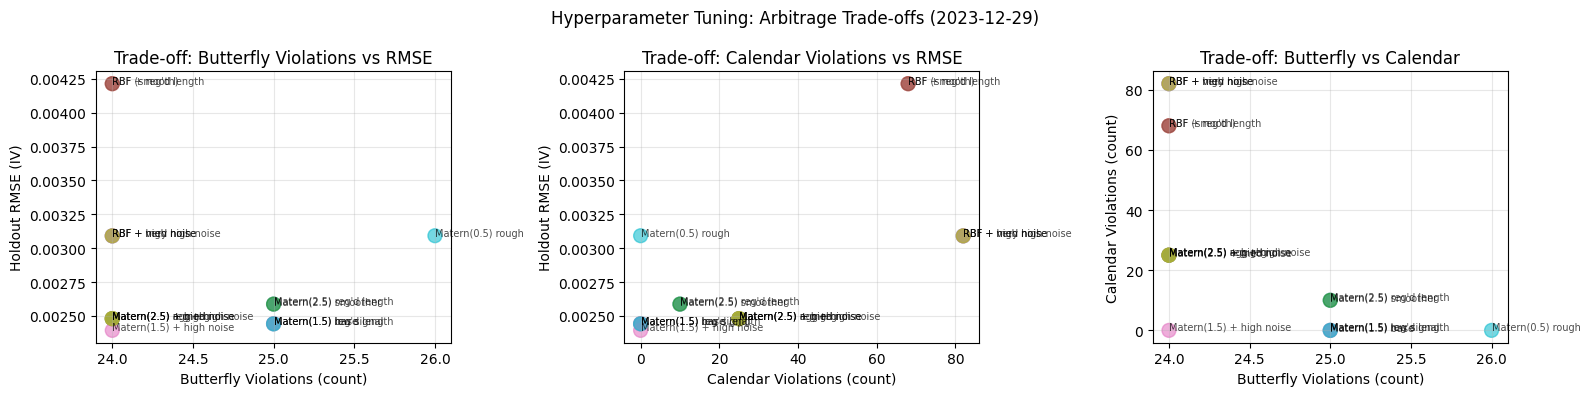


Best Configuration (PRIORITIZED: by Calendar Violations): Matern(1.5) base
Training RMSE (IV):     0.001319
Holdout RMSE (IV):      0.002443
Butterfly min g(k):     -1.4706e+00
Butterfly Violations:   25
Calendar Violations:    0
Fit Time:               0.302s


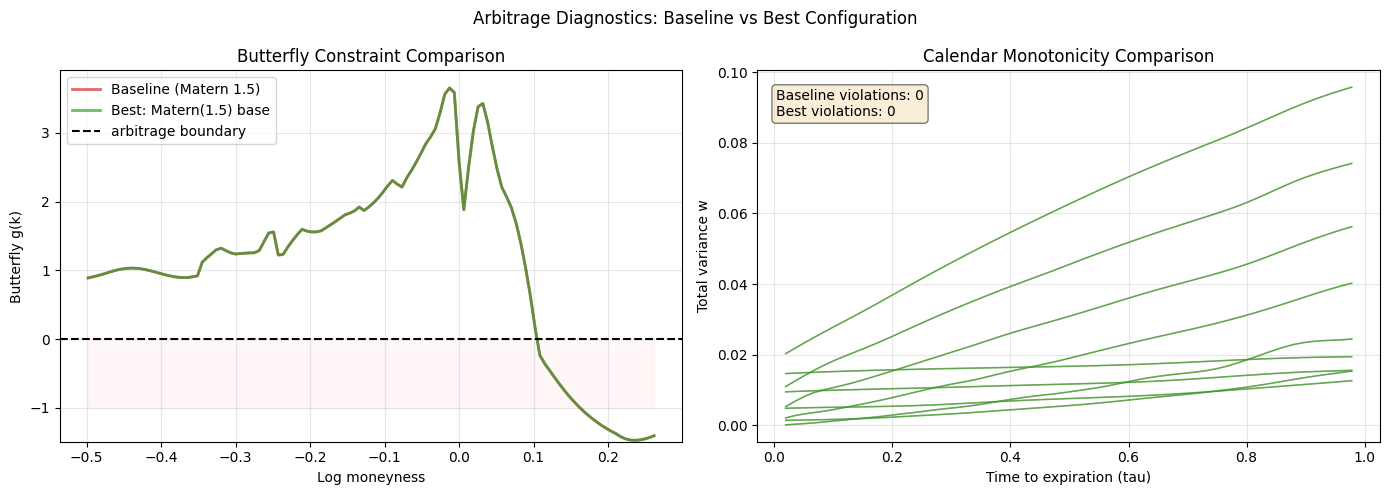

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

scatter1 = axes[0].scatter(results_df["Butterfly Violations"], results_df["RMSE IV"], s=100, alpha=0.6, c=range(len(results_df)), cmap="tab10")
for i, row in results_df.iterrows():
    axes[0].annotate(row["Config"], (row["Butterfly Violations"], row["RMSE IV"]), fontsize=7, alpha=0.7)
axes[0].set_xlabel("Butterfly Violations (count)")
axes[0].set_ylabel("Holdout RMSE (IV)")
axes[0].set_title("Trade-off: Butterfly Violations vs RMSE")
axes[0].grid(alpha=0.3)

scatter2 = axes[1].scatter(results_df["Calendar Violations"], results_df["RMSE IV"], s=100, alpha=0.6, c=range(len(results_df)), cmap="tab10")
for i, row in results_df.iterrows():
    axes[1].annotate(row["Config"], (row["Calendar Violations"], row["RMSE IV"]), fontsize=7, alpha=0.7)
axes[1].set_xlabel("Calendar Violations (count)")
axes[1].set_ylabel("Holdout RMSE (IV)")
axes[1].set_title("Trade-off: Calendar Violations vs RMSE")
axes[1].grid(alpha=0.3)

scatter3 = axes[2].scatter(results_df["Butterfly Violations"], results_df["Calendar Violations"], s=100, alpha=0.6, c=range(len(results_df)), cmap="tab10")
for i, row in results_df.iterrows():
    axes[2].annotate(row["Config"], (row["Butterfly Violations"], row["Calendar Violations"]), fontsize=7, alpha=0.7)
axes[2].set_xlabel("Butterfly Violations (count)")
axes[2].set_ylabel("Calendar Violations (count)")
axes[2].set_title("Trade-off: Butterfly vs Calendar")
axes[2].grid(alpha=0.3)

plt.suptitle("Hyperparameter Tuning: Arbitrage Trade-offs (2023-12-29)")
plt.tight_layout()
plt.show()

best_result = results[best_calendar_idx]
gp_best = best_result["kernel_obj"]
x_scaler_best, y_scaler_best = best_result["scalers"]

print(f"\n{'='*100}")
print(f"Best Configuration (PRIORITIZED: by Calendar Violations): {best_result['config']}")
print(f"{'='*100}")
print(f"Training RMSE (IV):     {best_result['rmse_iv_train']:.6f}")
print(f"Holdout RMSE (IV):      {best_result['rmse_iv_holdout']:.6f}")
print(f"Butterfly min g(k):     {best_result['butterfly_min_g']:+.4e}")
print(f"Butterfly Violations:   {best_result['butterfly_violations']}")
print(f"Calendar Violations:    {best_result['calendar_violations']}")
print(f"Fit Time:               {best_result['fit_time']:.3f}s")

def gp_surface_w_best(k_vals, tau_vals):
    k_arr, tau_arr = np.broadcast_arrays(
        np.asarray(k_vals, dtype=float),
        np.asarray(tau_vals, dtype=float),
    )
    X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
    mu_tv, _ = predict_total_var(gp_best, x_scaler_best, y_scaler_best, X_raw)
    return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)

g_curve_best = butterfly_g(gp_surface_w_best, kline, tau_g, eps=eps_k)
cal_lines_best = np.array([gp_surface_w_best(np.full_like(tau_fine, k0), tau_fine) for k0 in k_fixed])
cal_viol_best = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines_best))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(kline, g_curve, color="tab:red", linewidth=2, label="Baseline (Matern 1.5)", alpha=0.7)
ax1.plot(kline, g_curve_best, color="tab:green", linewidth=2, label=f"Best: {best_result['config']}", alpha=0.7)
ax1.axhline(0.0, color="black", linestyle="--", linewidth=1.5, label="arbitrage boundary")
ax1.fill_between(kline, -1, 0, color="red", alpha=0.03)
ax1.set_ylim(bottom=min(-0.2, min(np.nanmin(g_curve), np.nanmin(g_curve_best)) - 0.02))
ax1.set_xlabel("Log moneyness")
ax1.set_ylabel("Butterfly g(k)")
ax1.set_title("Butterfly Constraint Comparison")
ax1.legend()
ax1.grid(alpha=0.3)

for line, k0 in zip(cal_lines, k_fixed):
    ax2.plot(tau_fine, line, linewidth=0.8, color="tab:red", alpha=0.4)
for line, k0 in zip(cal_lines_best, k_fixed):
    ax2.plot(tau_fine, line, linewidth=1.2, color="tab:green", alpha=0.7, label=f"k={k0:.2f}" if k0 == k_fixed[0] else "")
ax2.set_xlabel("Time to expiration (tau)")
ax2.set_ylabel("Total variance w")
ax2.set_title("Calendar Monotonicity Comparison")
ax2.text(0.03, 0.95, f"Baseline violations: {calendar_violations}\nBest violations: {cal_viol_best}", 
         transform=ax2.transAxes, va="top", fontsize=10, bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
ax2.grid(alpha=0.3)

plt.suptitle(f"Arbitrage Diagnostics: Baseline vs Best Configuration")
plt.tight_layout()
plt.show()

## Analysis: TSLA on 2023-12-29 (Train/Holdout RMSE and Arbitrage)

This section mirrors the SPX analysis above, now using `TARGET_TICKER = "TSLA"` and `TARGET_DATE = "2023-12-29"`.

=== Analysis for TSLA on 2023-12-29 ===\n
Training set (500 samples):
  IV RMSE:  0.001627
  IV MAE:   0.000918
\nHoldout set (301 samples):
  IV RMSE:  0.002533
  IV MAE:   0.001322
\n=== Arbitrage Analysis ===\n
Butterfly check: min g(k) = -2.5400e-01; negative grid points = 34
Calendar check: 0 decreases of w in tau across 9 fixed-k lines


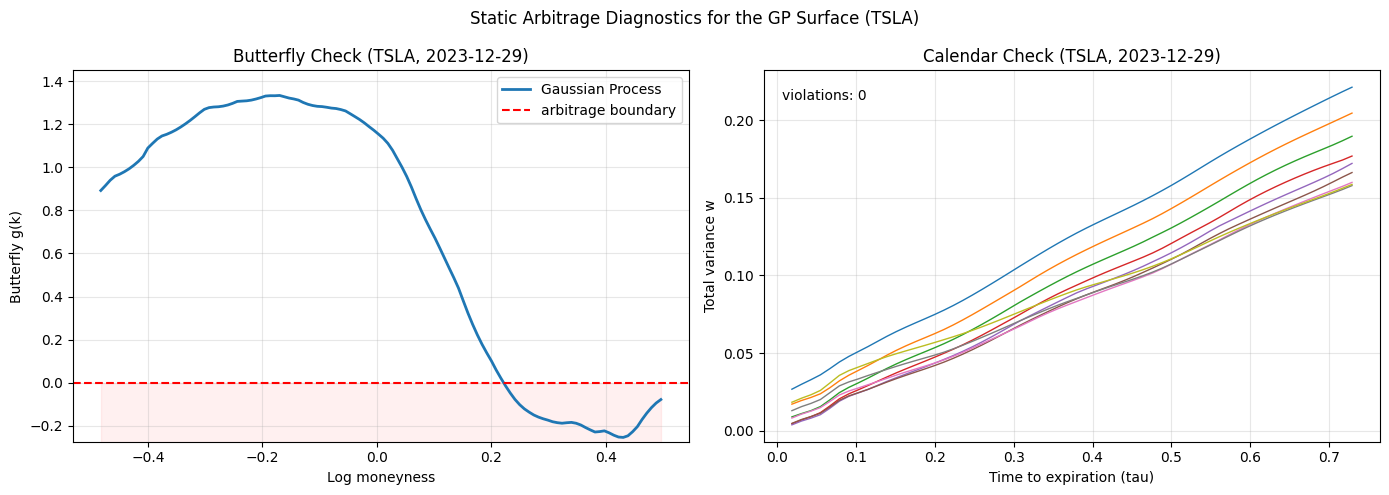

\nTuning 16 kernel configurations on TSLA (2023-12-29)
Matern(1.5) base               | RMSE_IV: 0.002533 | min_g: -2.540e-01 | butterfly_viol:  34 | cal_viol:  0 | fit: 0.307s
Matern(2.5) smoother           | RMSE_IV: 0.002514 | min_g: -2.305e-01 | butterfly_viol:  34 | cal_viol:  3 | fit: 0.287s
Matern(2.5) + med noise        | RMSE_IV: 0.002643 | min_g: -2.263e-01 | butterfly_viol:  34 | cal_viol:  1 | fit: 0.356s
Matern(2.5) + high noise       | RMSE_IV: 0.002643 | min_g: -2.263e-01 | butterfly_viol:  34 | cal_viol:  1 | fit: 0.347s
Matern(2.5) reg'd length       | RMSE_IV: 0.002514 | min_g: -2.305e-01 | butterfly_viol:  34 | cal_viol:  3 | fit: 0.288s
RBF (smooth)                   | RMSE_IV: 0.003390 | min_g: -2.692e-01 | butterfly_viol:  32 | cal_viol: 113 | fit: 0.259s
RBF + med noise                | RMSE_IV: 0.008435 | min_g: -2.266e-01 | butterfly_viol:  30 | cal_viol: 28 | fit: 0.197s
RBF + high noise               | RMSE_IV: 0.008435 | min_g: -2.266e-01 | butterfly_viol:  

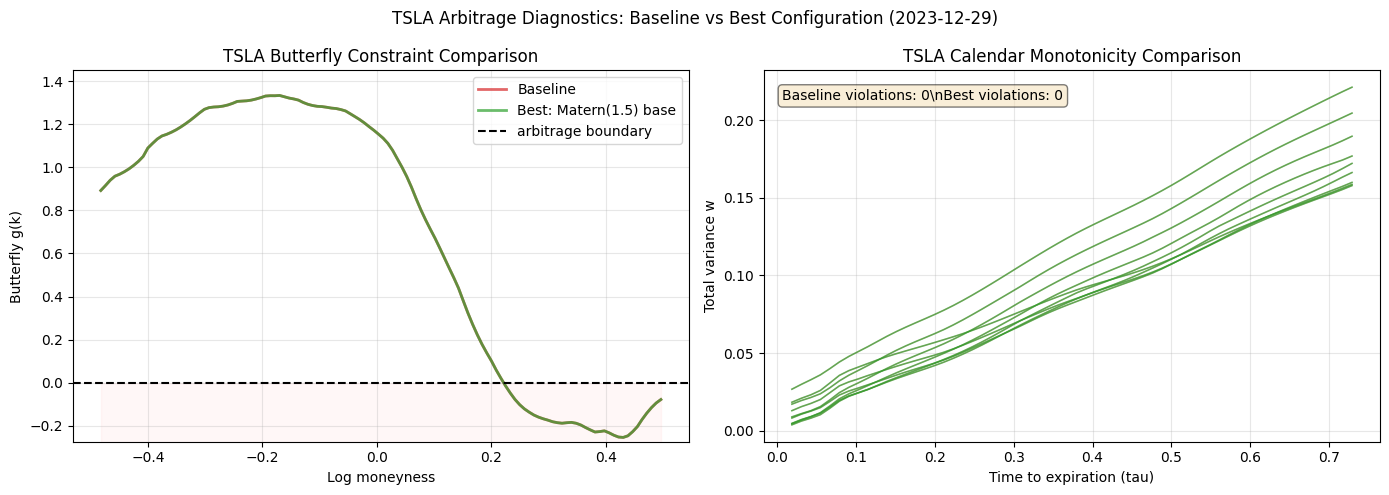

In [16]:
TARGET_DATE_TSLA = "2023-12-29"
TARGET_TICKER_TSLA = "TSLA"

# Filter data for the target date/ticker
tsla_df = df[(df["quote_date"] == TARGET_DATE_TSLA) & (df["ticker"] == TARGET_TICKER_TSLA)].copy()

if tsla_df.empty:
    print(f"No data found for {TARGET_TICKER_TSLA} on {TARGET_DATE_TSLA}")
else:
    # Use the same split style as above, with a small safety fallback for smaller slices.
    train_size_tsla = 500 if len(tsla_df) > 550 else max(50, int(0.8 * len(tsla_df)))
    train_tsla, holdout_tsla = split_train_holdout(tsla_df, train_size=train_size_tsla, seed=0)

    # Baseline GP fit
    gp_tsla, x_scaler_tsla, y_scaler_tsla = fit_gp_surface(train_tsla, random_state=0)

    # Predictions on train
    X_train_tsla = np.column_stack([
        train_tsla["log_moneyness"].to_numpy(),
        train_tsla["tau"].to_numpy(),
    ])
    mu_tv_train_tsla, _ = predict_total_var(gp_tsla, x_scaler_tsla, y_scaler_tsla, X_train_tsla)
    mu_tv_train_tsla = np.clip(mu_tv_train_tsla, 1e-12, None)
    pred_iv_train_tsla = np.sqrt(mu_tv_train_tsla / np.maximum(train_tsla["tau"].to_numpy(), 1e-12))
    obs_iv_train_tsla = train_tsla["iv"].to_numpy()

    # Predictions on holdout
    X_holdout_tsla = np.column_stack([
        holdout_tsla["log_moneyness"].to_numpy(),
        holdout_tsla["tau"].to_numpy(),
    ])
    mu_tv_holdout_tsla, _ = predict_total_var(gp_tsla, x_scaler_tsla, y_scaler_tsla, X_holdout_tsla)
    mu_tv_holdout_tsla = np.clip(mu_tv_holdout_tsla, 1e-12, None)
    pred_iv_holdout_tsla = np.sqrt(mu_tv_holdout_tsla / np.maximum(holdout_tsla["tau"].to_numpy(), 1e-12))
    obs_iv_holdout_tsla = holdout_tsla["iv"].to_numpy()

    rmse_iv_train_tsla = np.sqrt(np.mean((pred_iv_train_tsla - obs_iv_train_tsla) ** 2))
    rmse_iv_holdout_tsla = np.sqrt(np.mean((pred_iv_holdout_tsla - obs_iv_holdout_tsla) ** 2))
    mae_iv_train_tsla = np.mean(np.abs(pred_iv_train_tsla - obs_iv_train_tsla))
    mae_iv_holdout_tsla = np.mean(np.abs(pred_iv_holdout_tsla - obs_iv_holdout_tsla))

    print(f"=== Analysis for {TARGET_TICKER_TSLA} on {TARGET_DATE_TSLA} ===\\n")
    print(f"Training set ({len(train_tsla)} samples):")
    print(f"  IV RMSE:  {rmse_iv_train_tsla:.6f}")
    print(f"  IV MAE:   {mae_iv_train_tsla:.6f}")
    print(f"\\nHoldout set ({len(holdout_tsla)} samples):")
    print(f"  IV RMSE:  {rmse_iv_holdout_tsla:.6f}")
    print(f"  IV MAE:   {mae_iv_holdout_tsla:.6f}")

    def gp_surface_w_tsla(k_vals, tau_vals):
        k_arr, tau_arr = np.broadcast_arrays(
            np.asarray(k_vals, dtype=float),
            np.asarray(tau_vals, dtype=float),
        )
        X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
        mu_tv, _ = predict_total_var(gp_tsla, x_scaler_tsla, y_scaler_tsla, X_raw)
        return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)

    # Representative expiry slice
    if "expire_date" in tsla_df.columns:
        rep_expiry_tsla = tsla_df["expire_date"].value_counts().idxmax()
        rep_slice_tsla = tsla_df[tsla_df["expire_date"] == rep_expiry_tsla].copy()
    else:
        rep_slice_tsla = tsla_df.copy()

    tau_g_tsla = float(rep_slice_tsla["tau"].median())
    kline_tsla = np.linspace(rep_slice_tsla["log_moneyness"].min(), rep_slice_tsla["log_moneyness"].max(), 120)
    eps_k_tsla = max(1e-5, 1e-4 * (kline_tsla.max() - kline_tsla.min()))

    # Baseline arbitrage checks
    g_curve_tsla = butterfly_g(gp_surface_w_tsla, kline_tsla, tau_g_tsla, eps=eps_k_tsla)
    negative_g_tsla = int(np.sum(g_curve_tsla < -1e-8))
    worst_g_tsla = float(np.nanmin(g_curve_tsla))

    tau_fine_tsla = np.linspace(tsla_df["tau"].min(), tsla_df["tau"].max(), 60)
    k_fixed_tsla = np.linspace(tsla_df["log_moneyness"].min(), tsla_df["log_moneyness"].max(), 9)
    cal_lines_tsla = np.array([gp_surface_w_tsla(np.full_like(tau_fine_tsla, k0), tau_fine_tsla) for k0 in k_fixed_tsla])
    calendar_violations_tsla = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines_tsla))

    print("\\n=== Arbitrage Analysis ===\\n")
    print(f"Butterfly check: min g(k) = {worst_g_tsla:+.4e}; negative grid points = {negative_g_tsla}")
    print(f"Calendar check: {calendar_violations_tsla} decreases of w in tau across {len(k_fixed_tsla)} fixed-k lines")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(kline_tsla, g_curve_tsla, color="tab:blue", linewidth=2, label="Gaussian Process")
    ax1.axhline(0.0, color="red", linestyle="--", linewidth=1.5, label="arbitrage boundary")
    ax1.fill_between(kline_tsla, -1, 0, color="red", alpha=0.06)
    ax1.set_ylim(bottom=min(-0.2, np.nanmin(g_curve_tsla) - 0.02))
    ax1.set_xlabel("Log moneyness")
    ax1.set_ylabel("Butterfly g(k)")
    ax1.set_title(f"Butterfly Check ({TARGET_TICKER_TSLA}, {TARGET_DATE_TSLA})")
    ax1.legend()
    ax1.grid(alpha=0.3)

    for line, k0 in zip(cal_lines_tsla, k_fixed_tsla):
        ax2.plot(tau_fine_tsla, line, linewidth=1)
    ax2.set_xlabel("Time to expiration (tau)")
    ax2.set_ylabel("Total variance w")
    ax2.set_title(f"Calendar Check ({TARGET_TICKER_TSLA}, {TARGET_DATE_TSLA})")
    ax2.text(0.03, 0.95, f"violations: {calendar_violations_tsla}", transform=ax2.transAxes, va="top")
    ax2.grid(alpha=0.3)

    plt.suptitle("Static Arbitrage Diagnostics for the GP Surface (TSLA)")
    plt.tight_layout()
    plt.show()

    # Hyperparameter tuning (same structure as above)
    if "kernel_configs" not in globals():
        from sklearn.gaussian_process.kernels import RBF
        kernel_configs = [
            ("Matern(1.5) base", 
             lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
            ("Matern(2.5) smoother", 
             lambda: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(nu=2.5, length_scale=[1.0, 1.0], length_scale_bounds=(1e-3, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
            ("RBF (smooth)", 
             lambda: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0, 1.0], length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-4, noise_level_bounds=(1e-5, 1e-1))),
        ]

    import time
    results_tsla = []

    print(f"\\nTuning {len(kernel_configs)} kernel configurations on {TARGET_TICKER_TSLA} ({TARGET_DATE_TSLA})")
    print("=" * 100)

    X_train_tune_tsla = np.column_stack([
        train_tsla["log_moneyness"].to_numpy(),
        train_tsla["tau"].to_numpy(),
    ])
    y_train_tune_tsla = train_tsla["total_var"].to_numpy()

    X_hold_tune_tsla = np.column_stack([
        holdout_tsla["log_moneyness"].to_numpy(),
        holdout_tsla["tau"].to_numpy(),
    ])

    for config_name, kernel_fn in kernel_configs:
        try:
            start_time = time.time()

            kernel = kernel_fn()
            gp_tune_tsla = GaussianProcessRegressor(kernel=kernel, normalize_y=False, random_state=0)

            x_scaler_tune_tsla = StandardScaler()
            y_scaler_tune_tsla = StandardScaler()
            X_train_scaled_tsla = x_scaler_tune_tsla.fit_transform(X_train_tune_tsla)
            y_train_scaled_tsla = y_scaler_tune_tsla.fit_transform(y_train_tune_tsla.reshape(-1, 1)).ravel()

            gp_tune_tsla.fit(X_train_scaled_tsla, y_train_scaled_tsla)
            fit_time_tsla = time.time() - start_time

            mu_tv_train_tune_tsla, _ = predict_total_var(gp_tune_tsla, x_scaler_tune_tsla, y_scaler_tune_tsla, X_train_tune_tsla)
            mu_tv_train_tune_tsla = np.clip(mu_tv_train_tune_tsla, 1e-12, None)
            pred_iv_train_tune_tsla = np.sqrt(mu_tv_train_tune_tsla / np.maximum(train_tsla["tau"].to_numpy(), 1e-12))
            obs_iv_train_tune_tsla = train_tsla["iv"].to_numpy()
            rmse_iv_train_tune_tsla = np.sqrt(np.mean((pred_iv_train_tune_tsla - obs_iv_train_tune_tsla) ** 2))

            mu_tv_hold_tune_tsla, _ = predict_total_var(gp_tune_tsla, x_scaler_tune_tsla, y_scaler_tune_tsla, X_hold_tune_tsla)
            mu_tv_hold_tune_tsla = np.clip(mu_tv_hold_tune_tsla, 1e-12, None)
            pred_iv_hold_tune_tsla = np.sqrt(mu_tv_hold_tune_tsla / np.maximum(holdout_tsla["tau"].to_numpy(), 1e-12))
            obs_iv_hold_tune_tsla = holdout_tsla["iv"].to_numpy()
            rmse_iv_hold_tune_tsla = np.sqrt(np.mean((pred_iv_hold_tune_tsla - obs_iv_hold_tune_tsla) ** 2))

            def gp_surface_w_tune_tsla(k_vals, tau_vals):
                k_arr, tau_arr = np.broadcast_arrays(
                    np.asarray(k_vals, dtype=float),
                    np.asarray(tau_vals, dtype=float),
                )
                X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
                mu_tv, _ = predict_total_var(gp_tune_tsla, x_scaler_tune_tsla, y_scaler_tune_tsla, X_raw)
                return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)

            g_curve_tune_tsla = butterfly_g(gp_surface_w_tune_tsla, kline_tsla, tau_g_tsla, eps=eps_k_tsla)
            neg_g_tune_tsla = int(np.sum(g_curve_tune_tsla < -1e-8))
            worst_g_tune_tsla = float(np.nanmin(g_curve_tune_tsla))

            cal_lines_tune_tsla = np.array([gp_surface_w_tune_tsla(np.full_like(tau_fine_tsla, k0), tau_fine_tsla) for k0 in k_fixed_tsla])
            cal_viol_tune_tsla = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines_tune_tsla))

            results_tsla.append({
                "config": config_name,
                "rmse_iv_train": rmse_iv_train_tune_tsla,
                "rmse_iv_holdout": rmse_iv_hold_tune_tsla,
                "butterfly_min_g": worst_g_tune_tsla,
                "butterfly_violations": neg_g_tune_tsla,
                "calendar_violations": cal_viol_tune_tsla,
                "fit_time": fit_time_tsla,
                "kernel_obj": gp_tune_tsla,
                "scalers": (x_scaler_tune_tsla, y_scaler_tune_tsla),
            })

            print(f"{config_name:30s} | RMSE_IV: {rmse_iv_hold_tune_tsla:.6f} | min_g: {worst_g_tune_tsla:+.3e} | butterfly_viol: {neg_g_tune_tsla:3d} | cal_viol: {cal_viol_tune_tsla:2d} | fit: {fit_time_tsla:.3f}s")

        except Exception as e:
            print(f"{config_name:30s} | ERROR: {str(e)[:60]}")

    print("=" * 100)

    if results_tsla:
        results_df_tsla = pd.DataFrame([
            {
                "Config": r["config"],
                "RMSE IV": r["rmse_iv_holdout"],
                "min g(k)": r["butterfly_min_g"],
                "Butterfly Violations": r["butterfly_violations"],
                "Calendar Violations": r["calendar_violations"],
                "Fit Time (s)": r["fit_time"],
            }
            for r in results_tsla
        ])

        print("\\nTSLA hyperparameter results (sorted by butterfly violations):")
        print(results_df_tsla.sort_values("Butterfly Violations").to_string(index=False))

        print("\\nTSLA hyperparameter results (sorted by calendar violations):")
        print(results_df_tsla.sort_values("Calendar Violations").to_string(index=False))

        best_calendar_idx_tsla = results_df_tsla["Calendar Violations"].idxmin()
        best_result_tsla = results_tsla[best_calendar_idx_tsla]

        print(f"\\n{'='*100}")
        print(f"Best Configuration (TSLA, by Calendar Violations): {best_result_tsla['config']}")
        print(f"{'='*100}")
        print(f"Training RMSE (IV):     {best_result_tsla['rmse_iv_train']:.6f}")
        print(f"Holdout RMSE (IV):      {best_result_tsla['rmse_iv_holdout']:.6f}")
        print(f"Butterfly min g(k):     {best_result_tsla['butterfly_min_g']:+.4e}")
        print(f"Butterfly Violations:   {best_result_tsla['butterfly_violations']}")
        print(f"Calendar Violations:    {best_result_tsla['calendar_violations']}")
        print(f"Fit Time:               {best_result_tsla['fit_time']:.3f}s")

        gp_best_tsla = best_result_tsla["kernel_obj"]
        x_scaler_best_tsla, y_scaler_best_tsla = best_result_tsla["scalers"]

        def gp_surface_w_best_tsla(k_vals, tau_vals):
            k_arr, tau_arr = np.broadcast_arrays(
                np.asarray(k_vals, dtype=float),
                np.asarray(tau_vals, dtype=float),
            )
            X_raw = np.column_stack([k_arr.ravel(), tau_arr.ravel()])
            mu_tv, _ = predict_total_var(gp_best_tsla, x_scaler_best_tsla, y_scaler_best_tsla, X_raw)
            return np.clip(mu_tv, 1e-10, None).reshape(k_arr.shape)

        g_curve_best_tsla = butterfly_g(gp_surface_w_best_tsla, kline_tsla, tau_g_tsla, eps=eps_k_tsla)
        cal_lines_best_tsla = np.array([gp_surface_w_best_tsla(np.full_like(tau_fine_tsla, k0), tau_fine_tsla) for k0 in k_fixed_tsla])
        cal_viol_best_tsla = int(sum((np.diff(line) < -1e-10).sum() for line in cal_lines_best_tsla))

        fig, (bx1, bx2) = plt.subplots(1, 2, figsize=(14, 5))

        bx1.plot(kline_tsla, g_curve_tsla, color="tab:red", linewidth=2, label="Baseline", alpha=0.7)
        bx1.plot(kline_tsla, g_curve_best_tsla, color="tab:green", linewidth=2, label=f"Best: {best_result_tsla['config']}", alpha=0.7)
        bx1.axhline(0.0, color="black", linestyle="--", linewidth=1.5, label="arbitrage boundary")
        bx1.fill_between(kline_tsla, -1, 0, color="red", alpha=0.03)
        bx1.set_ylim(bottom=min(-0.2, min(np.nanmin(g_curve_tsla), np.nanmin(g_curve_best_tsla)) - 0.02))
        bx1.set_xlabel("Log moneyness")
        bx1.set_ylabel("Butterfly g(k)")
        bx1.set_title("TSLA Butterfly Constraint Comparison")
        bx1.legend()
        bx1.grid(alpha=0.3)

        for line in cal_lines_tsla:
            bx2.plot(tau_fine_tsla, line, linewidth=0.8, color="tab:red", alpha=0.4)
        for line, k0 in zip(cal_lines_best_tsla, k_fixed_tsla):
            bx2.plot(tau_fine_tsla, line, linewidth=1.2, color="tab:green", alpha=0.7, label=f"k={k0:.2f}" if k0 == k_fixed_tsla[0] else "")
        bx2.set_xlabel("Time to expiration (tau)")
        bx2.set_ylabel("Total variance w")
        bx2.set_title("TSLA Calendar Monotonicity Comparison")
        bx2.text(
            0.03,
            0.95,
            f"Baseline violations: {calendar_violations_tsla}\\nBest violations: {cal_viol_best_tsla}",
            transform=bx2.transAxes,
            va="top",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
        )
        bx2.grid(alpha=0.3)

        plt.suptitle(f"TSLA Arbitrage Diagnostics: Baseline vs Best Configuration ({TARGET_DATE_TSLA})")
        plt.tight_layout()
        plt.show()
